# <center> Computer Vision 2: Eye fixation prediction project </center>
#### <center> Summer semester 2026 </center>
<center> By Narges Baba Ahmadi and Niloufar Baba Ahmadi </center>

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import json
import torch
import matplotlib.pyplot as plt

# Connect to scripts folder
sys.path.append("./main")
from dataset import SaliencyDataset
from training_framework import TrainingConfig, TrainingFramework
from utils import plot_reconstruction, plot_saved_loss

DATA_DIR = "./cv2_project_data/"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Jupyter Framework Engine Initialized on: {device}")

# Universal shared dataset definitions
train_dataset = SaliencyDataset(DATA_DIR, "train_images.txt", "train_fixations.txt")
val_dataset = SaliencyDataset(DATA_DIR, "val_images.txt", "val_fixations.txt")

Jupyter Framework Engine Initialized on: mps


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..1.0000000236034394].


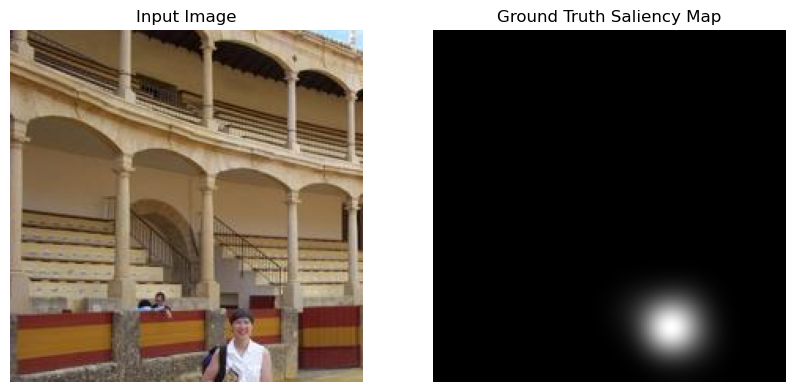

In [22]:
# initializing the dataset using the text files 
train_dataset = SaliencyDataset(DATA_DIR, "train_images.txt", "train_fixations.txt")

# random image and its corresponding fixation map from the training dataset
sample_img, sample_fixation = train_dataset[440]

# visualize the image and its corresponding fixation map
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_to_show)
axes[0].set_title("Input Image")
axes[0].axis('off')

axes[1].imshow(sample_fixation.squeeze(0).numpy(), cmap='gray')
axes[1].set_title("Ground Truth Saliency Map")
axes[1].axis('off')

plt.show()

## Experiment 1: ResNet-18 Baseline

In [14]:
from training_framework import TrainingConfig, TrainingFramework, BiologicallyAlignedSaliencyLoss
from model_resnet18 import BiologicallyOptimizedSaliencyNet

config_exp1 = TrainingConfig(
    experiment_name="resnet18_baseline",
    epochs=10,
    batch_size=32,
    learning_rate=1e-3,
    resume_training=True
)

model_exp1 = BiologicallyOptimizedSaliencyNet()
criterion_exp1 = BiologicallyAlignedSaliencyLoss() 

framework_exp1 = TrainingFramework(
    config=config_exp1, 
    model=model_exp1, 
    criterion=criterion_exp1,
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    base_dir="."
)

train_hist1, val_hist1 = framework_exp1.train()

Starting training: resnet18_baseline
Device: mps
Epochs: 0 -> 10
Epoch 1/10 | Train Loss: 1.3044 | Val Loss: 1.0371
Best model saved to: best_model_resnet18_baseline.pth
  ✓ New best validation loss: 1.0371
Epoch 2/10 | Train Loss: 0.8650 | Val Loss: 0.8611
Best model saved to: best_model_resnet18_baseline.pth
  ✓ New best validation loss: 0.8611
Epoch 3/10 | Train Loss: 0.7253 | Val Loss: 0.8384
Best model saved to: best_model_resnet18_baseline.pth
  ✓ New best validation loss: 0.8384
Epoch 4/10 | Train Loss: 0.6345 | Val Loss: 0.8224
Best model saved to: best_model_resnet18_baseline.pth
  ✓ New best validation loss: 0.8224
Epoch 5/10 | Train Loss: 0.5567 | Val Loss: 0.8018
Best model saved to: best_model_resnet18_baseline.pth
  ✓ New best validation loss: 0.8018
Epoch 6/10 | Train Loss: 0.4844 | Val Loss: 0.7961
Best model saved to: best_model_resnet18_baseline.pth
  ✓ New best validation loss: 0.7961
Epoch 7/10 | Train Loss: 0.4291 | Val Loss: 0.7961
Best model saved to: best_model_

 Saved single loss curve chart to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/loss_curve_resnet18_baseline.png


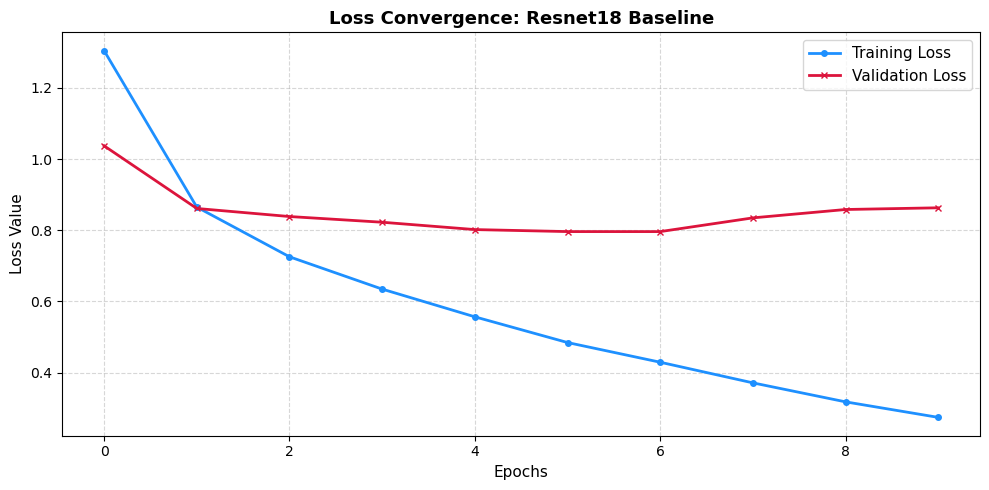

In [15]:
plot_saved_loss("resnet18_baseline", save_filename="loss_curve_resnet18_baseline.png")

/Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/./main/utils.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/visual_reconstruction_baseline_train_42.png


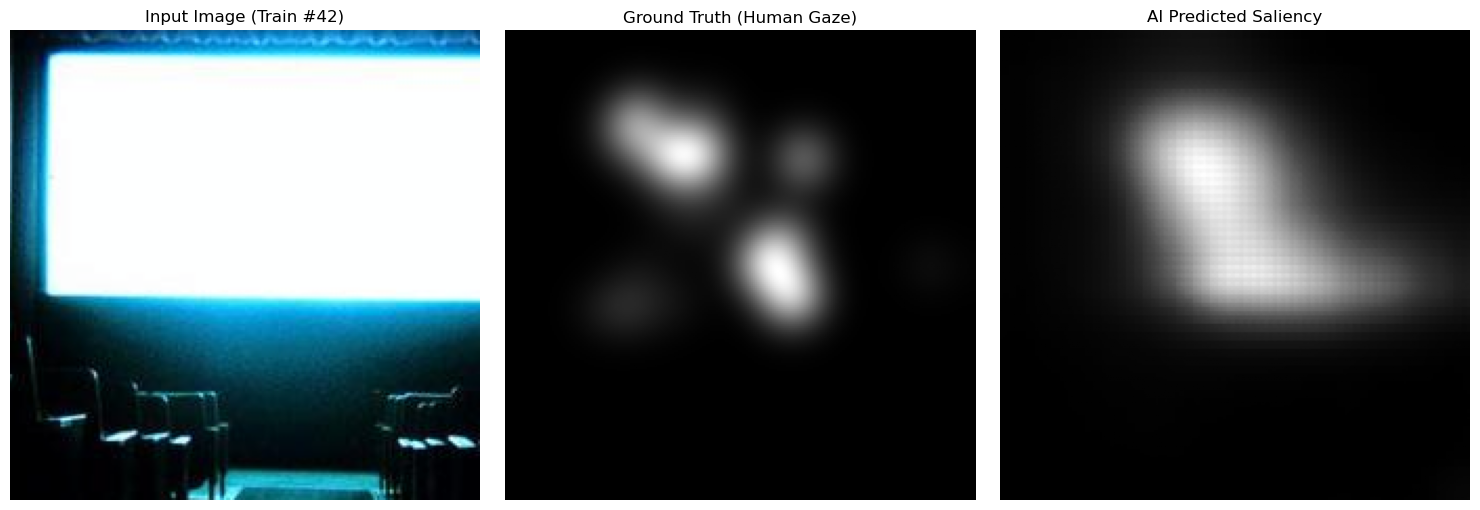

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/visual_reconstruction_baseline_val_42.png


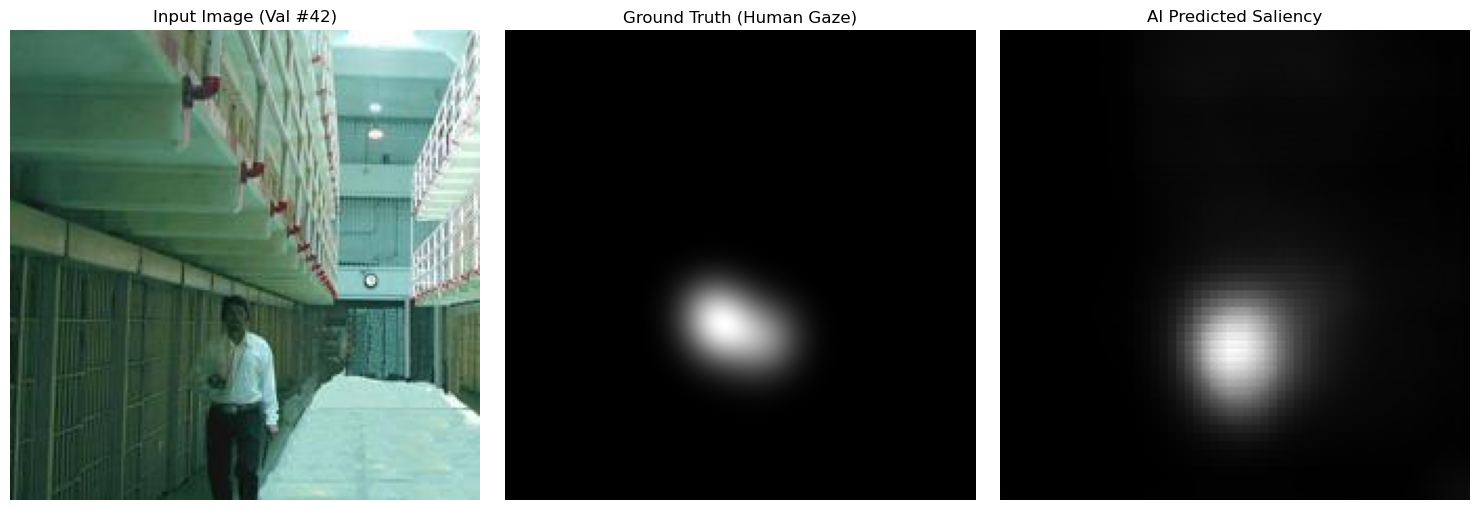

In [16]:
plot_reconstruction(
    sample_idx=42, 
    dataset_type="train", 
    weights_filename="best_model_resnet18_baseline.pth",
    save_filename="visual_reconstruction_baseline_train_42.png"
)

plot_reconstruction(
    sample_idx=42, 
    dataset_type="val", 
    weights_filename="best_model_resnet18_baseline.pth",
    save_filename="visual_reconstruction_baseline_val_42.png"
)

## Experiment 2: ResNet-18 Regularized

In [18]:
from training_framework import TrainingConfig, TrainingFramework, HybridSaliencyLoss
from model_resnet18 import BiologicallyOptimizedSaliencyNet

config_2a = TrainingConfig(
    experiment_name="resnet18_regularized",
    epochs=10,                          
    batch_size=32,
    learning_rate=1e-3,
    weight_decay=1e-4,                  # Active L2 penalty to suppress background noise connections
    resume_training=True,
    verbose=True
)

model_2a = BiologicallyOptimizedSaliencyNet()
criterion_2a = HybridSaliencyLoss(bce_weight=5.0, kl_weight=1.0)

framework_2a = TrainingFramework(
    config=config_2a,
    model=model_2a,
    criterion=criterion_2a,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    base_dir="."
)

train_hist_2a, val_hist_2a = framework_2a.train()

Starting training: resnet18_regularized
Device: mps
Epochs: 0 -> 10
Epoch 1/10 | Train Loss: 3.0152 | Val Loss: 1.8204
Best model saved to: best_model_resnet18_regularized.pth
  ✓ New best validation loss: 1.8204
Epoch 2/10 | Train Loss: 1.7628 | Val Loss: 1.7123
Best model saved to: best_model_resnet18_regularized.pth
  ✓ New best validation loss: 1.7123
Epoch 3/10 | Train Loss: 1.6625 | Val Loss: 1.6931
Best model saved to: best_model_resnet18_regularized.pth
  ✓ New best validation loss: 1.6931
Epoch 4/10 | Train Loss: 1.5647 | Val Loss: 1.7114
Epoch 5/10 | Train Loss: 1.4928 | Val Loss: 1.7592
Epoch 6/10 | Train Loss: 1.4083 | Val Loss: 1.6732
Best model saved to: best_model_resnet18_regularized.pth
  ✓ New best validation loss: 1.6732
Epoch 7/10 | Train Loss: 1.3446 | Val Loss: 1.7132
Epoch 8/10 | Train Loss: 1.2910 | Val Loss: 1.7695
Epoch 9/10 | Train Loss: 1.2190 | Val Loss: 1.6991
Epoch 10/10 | Train Loss: 1.1795 | Val Loss: 1.7302
Training completed! Best validation loss: 1.6

 Saved single loss curve chart to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/loss_curve_resnet18_regularized.png


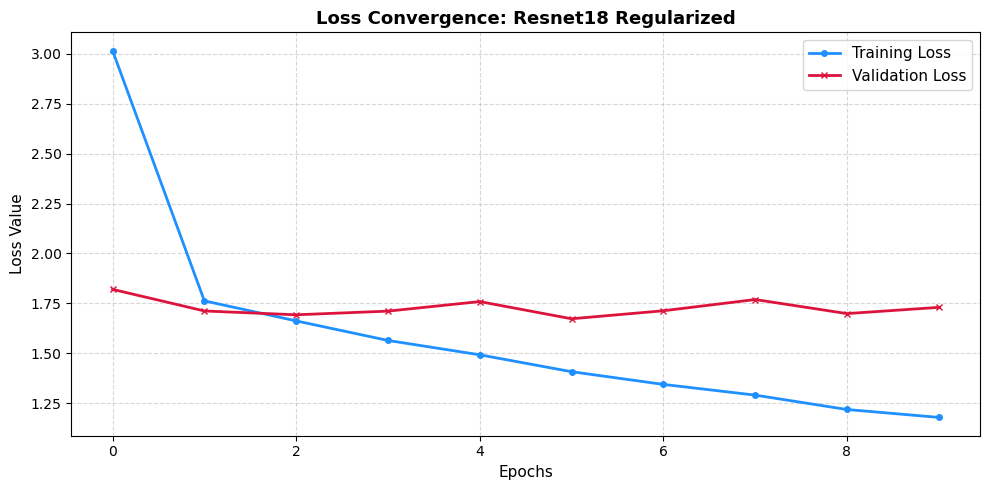

In [19]:
plot_saved_loss("resnet18_regularized", save_filename="loss_curve_resnet18_regularized.png")

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/visual_reconstruction_regularized_train_42.png


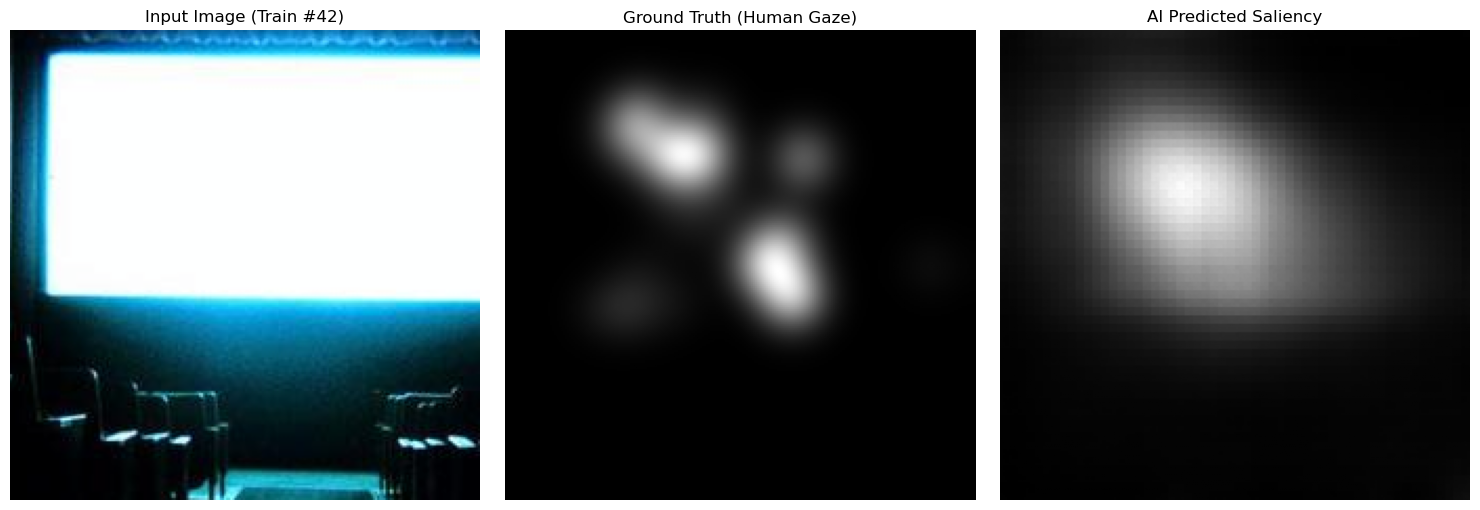

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/visual_reconstruction_regularized_val_42.png


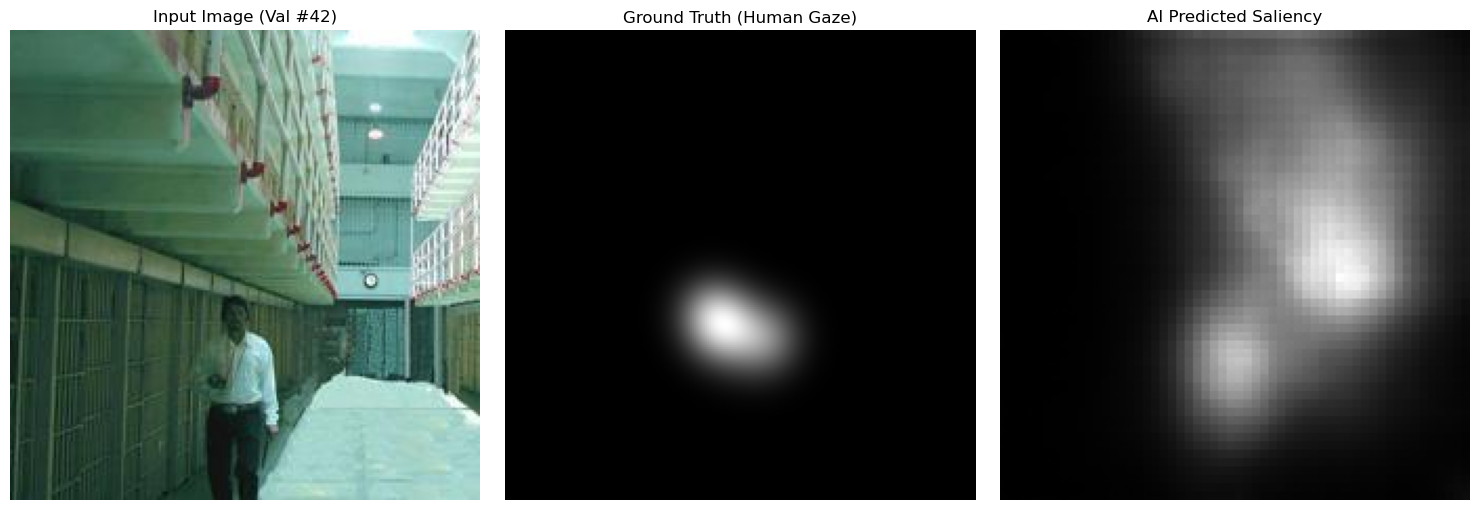

In [20]:
plot_reconstruction(
    sample_idx=42, 
    dataset_type="train", 
    weights_filename="best_model_resnet18_regularized.pth",
    save_filename="visual_reconstruction_regularized_train_42.png"
)

plot_reconstruction(
    sample_idx=42, 
    dataset_type="val", 
    weights_filename="best_model_resnet18_regularized.pth",
    save_filename="visual_reconstruction_regularized_val_42.png"
)

## Experiment 3: ResNet-18 Augmented

Deploying augmented pipeline on training split...
Starting training: resnet18_augmented_only
Device: mps
Epochs: 0 -> 10
Epoch 1/10 | Train Loss: 1.1700 | Val Loss: 0.9076
Best model saved to: best_model_resnet18_augmented_only.pth
  ✓ New best validation loss: 0.9076
Epoch 2/10 | Train Loss: 0.8669 | Val Loss: 0.8620
Best model saved to: best_model_resnet18_augmented_only.pth
  ✓ New best validation loss: 0.8620
Epoch 3/10 | Train Loss: 0.7907 | Val Loss: 0.8497
Best model saved to: best_model_resnet18_augmented_only.pth
  ✓ New best validation loss: 0.8497
Epoch 4/10 | Train Loss: 0.7527 | Val Loss: 0.7984
Best model saved to: best_model_resnet18_augmented_only.pth
  ✓ New best validation loss: 0.7984
Epoch 5/10 | Train Loss: 0.7276 | Val Loss: 0.8225
Epoch 6/10 | Train Loss: 0.6880 | Val Loss: 0.7744
Best model saved to: best_model_resnet18_augmented_only.pth
  ✓ New best validation loss: 0.7744
Epoch 7/10 | Train Loss: 0.6660 | Val Loss: 0.7892
Epoch 8/10 | Train Loss: 0.6414 | Val

/Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/./main/utils.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/val_reconstruction_augmented_only.png


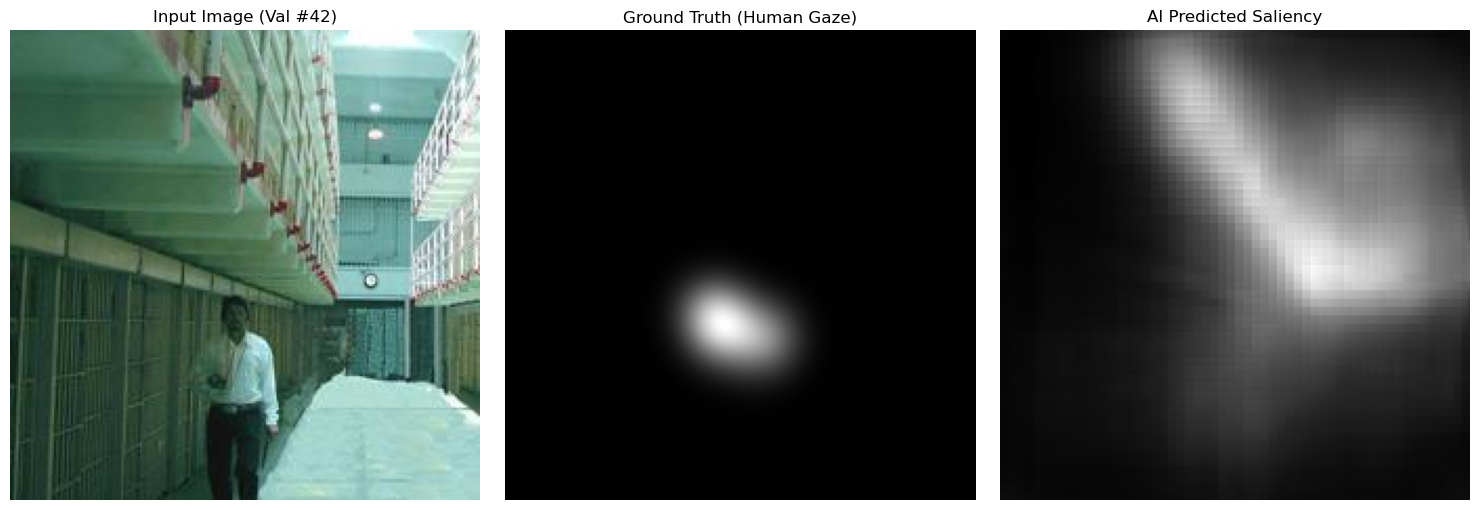

In [ ]:
from training_framework import TrainingConfig, TrainingFramework, BiologicallyAlignedSaliencyLoss
from dataset import AugmentedSaliencyDataset
from model_resnet18 import BiologicallyOptimizedSaliencyNet

DATA_DIR = "./cv2_project_data/"
print("Deploying augmented pipeline on training split...")
train_dataset_aug = AugmentedSaliencyDataset(DATA_DIR, "train_images.txt", "train_fixations.txt", is_training=True)

config_3 = TrainingConfig(
    experiment_name="resnet18_augmented_only",
    epochs=10,
    batch_size=32,
    learning_rate=1e-3,
    loss_class="BiologicallyAlignedSaliencyLoss",
    resume_training=True
)

model_3 = BiologicallyOptimizedSaliencyNet()
criterion_3 = BiologicallyAlignedSaliencyLoss()  # Pure KL baseline loss

framework_3 = TrainingFramework(
    config=config_3, model=model_3, criterion=criterion_3,
    train_dataset=train_dataset_aug, val_dataset=val_dataset, base_dir="."
)

# Run the training framework loop
train_hist_3, val_hist_3 = framework_3.train()

 Saved single loss curve chart to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/loss_curve_augmented_only.png


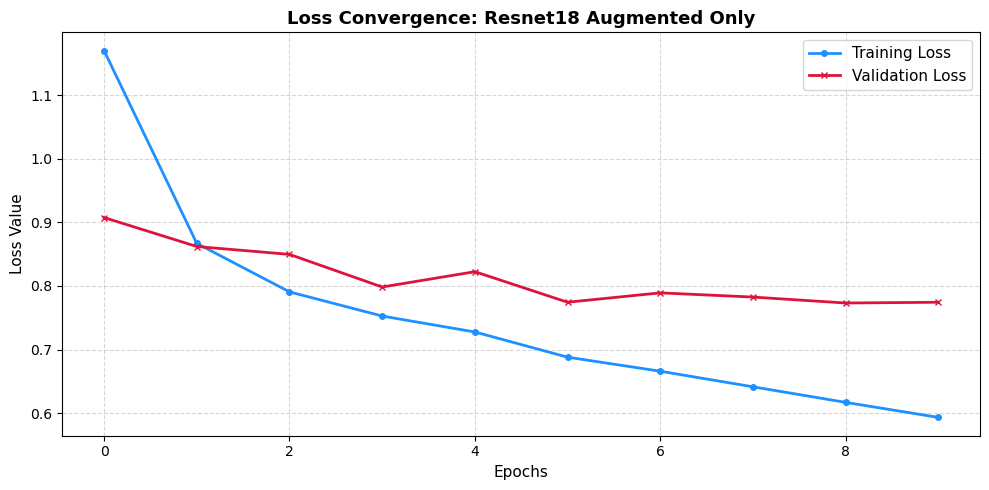

In [24]:
plot_saved_loss("resnet18_augmented_only", save_filename="loss_curve_augmented_only.png")

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/visual_reconstruction_augmented_only_train_42.png


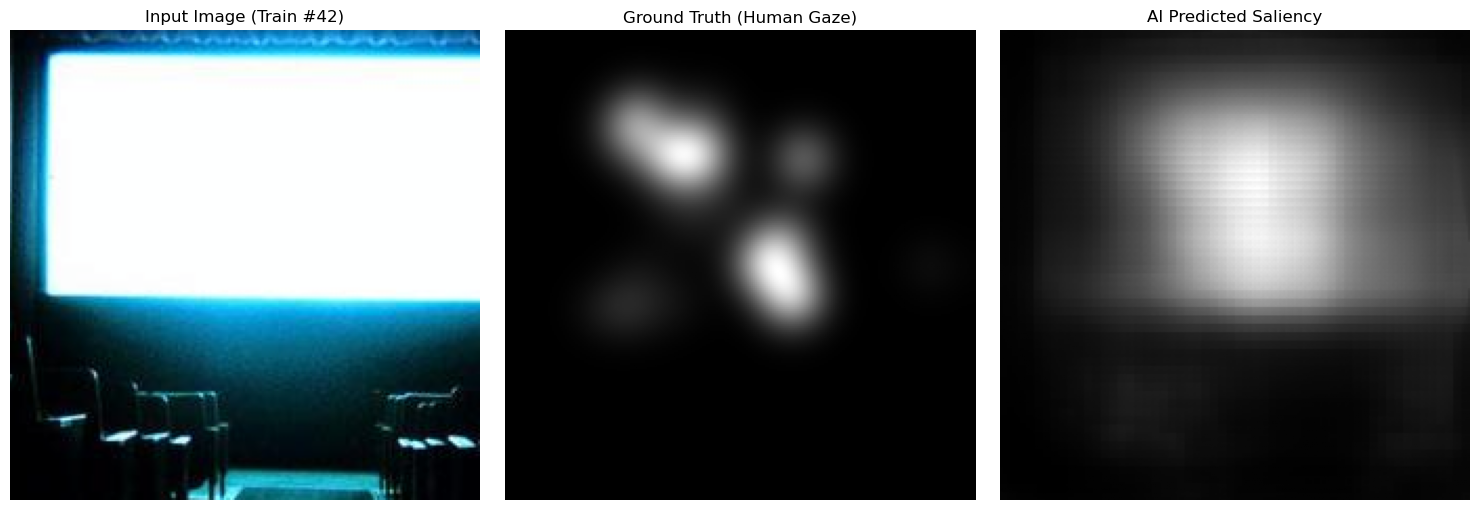

 Successfully saved reconstruction figure to: /Users/niloufarbabaahmadi/Desktop/Computer-Vision-2-Masters-Course/visual_reconstruction_augmented_only_val_42.png


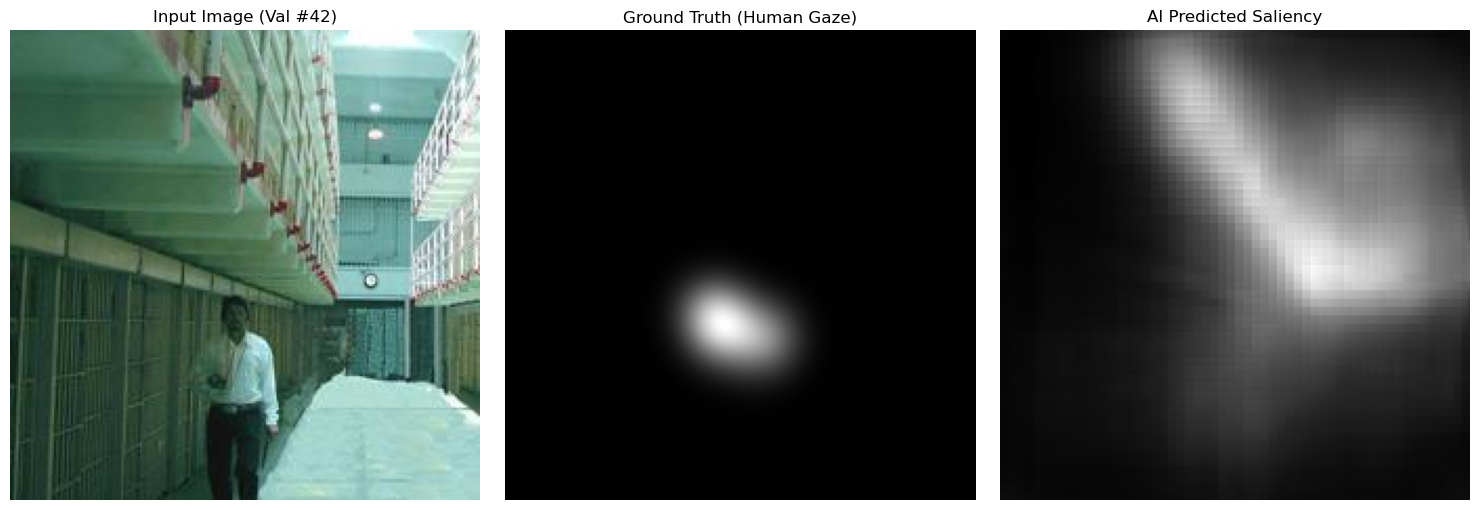

In [25]:
plot_reconstruction(
    sample_idx=42, 
    dataset_type="train", 
    weights_filename="best_model_resnet18_augmented_only.pth",
    save_filename="visual_reconstruction_augmented_only_train_42.png"
)

plot_reconstruction(
    sample_idx=42, 
    dataset_type="val", 
    weights_filename="best_model_resnet18_augmented_only.pth",
    save_filename="visual_reconstruction_augmented_only_val_42.png"
)

## Experiment 4: ResNet-50 baseline

In [ ]:
from model_resnet50 import ResNet50SaliencyNet
from training_framework import BiologicallyAlignedSaliencyLoss, TrainingConfig, TrainingFramework

config_4 = TrainingConfig(
    experiment_name="resnet50_baseline",
    epochs=10,
    batch_size=32,          
    learning_rate=1e-3,     
    model_class="ResNet50SaliencyNet",
    loss_class="BiologicallyAlignedSaliencyLoss"
)

model_4= ResNet50SaliencyNet()
criterion_4 = BiologicallyAlignedSaliencyLoss()

framework_4 = TrainingFramework(
    config=config_4,
    model=model_4,
    criterion=criterion_4,
    train_dataset=train_dataset,
    val_dataset=val_dataset
)

train_loss_baseline, val_loss_baseline = framework_4.train()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/niloufarbabaahmadi/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100.0%


Starting training: resnet50_baseline
Device: mps
Epochs: 0 -> 10
Epoch 1/10 | Train Loss: 1.2325 | Val Loss: 1.0348
Best model saved to: best_model_resnet50_baseline.pth
  ✓ New best validation loss: 1.0348


In [ ]:
plot_saved_loss("resnet50_baseline", save_filename="loss_curve_resnet50_baseline.png")

In [ ]:
plot_reconstruction(
    sample_idx=42, 
    dataset_type="train", 
    weights_filename="best_model_resnet50_baseline.pth",
    save_filename="visual_reconstruction_resnet50_baseline_train_42.png"
)

plot_reconstruction(
    sample_idx=42, 
    dataset_type="val", 
    weights_filename="best_model_resnet50_baseline.pth",
    save_filename="visual_reconstruction_resnet50_baseline_val_42.png"
)